# Аналитика B2C-маркетинговых контактов

Этот notebook показывает упрощённый полный аналитический цикл на синтетическом наборе из **10 000 строк и 10 столбцов**. Одна строка описывает один маркетинговый контакт с потребителем: например, показ рекламного сообщения по электронной почте, в социальной сети или поисковой рекламе.

Материал рассчитан на начинающих. Экономические и статистические показатели поясняются простыми словами, а исполняемые операции сопровождаются русскими комментариями.

Логика работы соответствует универсальному аналитическому пайплайну: бизнес-вопрос → проверка данных → очистка → расчёт показателей → визуализация → статистическая проверка → выводы и рекомендации.

## 1. Цель анализа

Цель — определить, какие маркетинговые каналы, кампании и клиентские сегменты связаны с кликами, покупками и выручкой.

Результат может использовать учебный руководитель маркетинга, чтобы сравнить эффективность каналов и понять, какие направления требуют дополнительной проверки.

В наборе рассматривается **B2C-маркетинг**, то есть продвижение товаров или услуг конечным потребителям. Выручка показывает сумму покупки после маркетингового контакта. Расход отражает учебную стоимость одного контакта. Разность между выручкой и расходом не является полной прибылью бизнеса, потому что в наборе нет себестоимости товара, зарплат, налогов и других затрат.

## 2. Аналитические вопросы и гипотезы

Проверяются пять вопросов:

1. Как меняются контакты, расходы, покупки и выручка по месяцам?
2. Какие каналы дают более высокий CTR и коэффициент конверсии?
3. Какие кампании имеют более высокий ROAS?
4. Как различается реакция новых, повторных и лояльных потребителей?
5. Связаны ли маркетинговый канал и факт покупки?

Рабочие гипотезы:

- ретаргетинг обычно показывает более высокую конверсию, потому что обращается к уже знакомой аудитории;
- поисковая реклама может давать больше кликов, но стоит дороже одного контакта;
- лояльные клиенты могут покупать чаще новых;
- канал и факт покупки могут быть статистически связаны.

Гипотеза — проверяемое предположение, а не заранее установленный факт.

## 3. Данные, единица наблюдения и ожидаемый результат

Источник — синтетический CSV-файл `b2c_marketing_contacts_10000.csv`. Данные охватывают 2025 год и не содержат сведений о реальных людях.

**Единица наблюдения, или grain:** один маркетинговый контакт. Поэтому `contact_id` должен быть уникальным после удаления полных дубликатов.

Ожидаемые результаты:

- очищенный CSV с теми же десятью исходными полями;
- таблицы маркетинговых показателей;
- временной, канальный, кампанийный и сегментный анализ;
- воронка «контакт → клик → покупка»;
- корреляционная матрица и тепловые карты;
- статистическая проверка связи канала с покупкой;
- итоговый дашборд и рекомендации.

## 4. Подготовка окружения

`pandas` работает с таблицами. `NumPy` выполняет числовые расчёты. `matplotlib` и `seaborn` строят графики. `SciPy` содержит статистические тесты.

Фиксированное случайное зерно делает повторяемыми расчёты, где используется случайная выборка, например bootstrap-оценка доверительного интервала.

In [1]:
# Импортируем Path для безопасной работы с путями к файлам.
from pathlib import Path
# Импортируем warnings для управления некритичными предупреждениями.
import warnings
# Импортируем NumPy для числовых расчётов.
import numpy as np
# Импортируем pandas для работы с таблицами.
import pandas as pd
# Импортируем matplotlib для построения графиков.
import matplotlib.pyplot as plt
# Импортируем seaborn для статистических графиков и тепловых карт.
import seaborn as sns
# Импортируем критерий хи-квадрат для таблиц сопряжённости.
from scipy.stats import chi2_contingency
# Импортируем display и Markdown для удобного вывода результатов.
from IPython.display import display, Markdown

# Скрываем только некритичные FutureWarning, чтобы учебный вывод оставался читаемым.
warnings.filterwarnings('ignore', category=FutureWarning)
# Фиксируем случайное зерно для воспроизводимых расчётов.
RANDOM_SEED = 20260801
# Создаём генератор случайных чисел с фиксированным зерном.
rng = np.random.default_rng(RANDOM_SEED)
# Устанавливаем спокойный стиль графиков.
sns.set_theme(style='whitegrid', context='notebook')
# Устанавливаем шрифт с поддержкой кириллицы.
plt.rcParams['font.family'] = 'DejaVu Sans'
# Устанавливаем размер графика по умолчанию.
plt.rcParams['figure.figsize'] = (11, 6)
# Показываем до 30 столбцов в таблицах pandas.
pd.set_option('display.max_columns', 30)
# Показываем числа с двумя знаками после запятой.
pd.set_option('display.float_format', lambda value: f'{value:,.2f}')

# Определяем рабочую папку как папку запуска notebook.
DATA_DIR = Path('.')
# Формируем путь к исходному CSV-файлу.
RAW_DATA_PATH = DATA_DIR / 'b2c_marketing_contacts_10000.csv'
# Формируем путь для сохранения очищенного CSV-файла.
CLEAN_DATA_PATH = DATA_DIR / 'b2c_marketing_contacts_clean.csv'
# Формируем путь для сохранения итогового дашборда.
DASHBOARD_PATH = DATA_DIR / 'b2c_marketing_dashboard.png'

## 5. Загрузка данных

Метод `pd.read_csv()` читает CSV-файл и создаёт `DataFrame`. DataFrame можно представить как программную таблицу со строками и столбцами.

После загрузки проверяются размер, начало и конец файла. Если ожидалось 10 000 строк, а загрузилось меньше, анализ нельзя продолжать без выяснения причины.

In [2]:
# Проверяем, что исходный CSV находится рядом с notebook.
assert RAW_DATA_PATH.exists(), f'Файл не найден: {RAW_DATA_PATH.resolve()}'
# Загружаем исходный CSV в таблицу raw_df.
raw_df = pd.read_csv(RAW_DATA_PATH, encoding='utf-8-sig')
# Печатаем количество строк и столбцов.
print(f'Размер исходного датасета: {raw_df.shape[0]:,} строк и {raw_df.shape[1]} столбцов.')
# Показываем первые пять строк.
display(raw_df.head())
# Показываем последние пять строк.
display(raw_df.tail())

Размер исходного датасета: 10,000 строк и 10 столбцов.


,contact_id,contact_date,channel,campaign_type,customer_segment,device_type,ad_cost_rub,clicked,converted,revenue_rub
0,MKT004700,2025-11-25,Медийная реклама,Программа лояльности,Лояльный,Планшет,4.03,0,0,0.00
1,MKT000670,2025-03-04,Поисковая реклама,Ретаргетинг,Новый,Мобильное устройство,16.88,0,0,0.00
2,MKT004793,2025-12-18,Поисковая реклама,Программа лояльности,Повторный,Компьютер,17.73,0,0,0.00
3,MKT005055,2025-03-29,Медийная реклама,Ретаргетинг,Лояльный,Мобильное устройство,5.05,0,0,0.00
4,MKT001308,2025-01-25,Email,Новый продукт,Повторный,Мобильное устройство,4.04,0,0,0.00


,contact_id,contact_date,channel,campaign_type,customer_segment,device_type,ad_cost_rub,clicked,converted,revenue_rub
9995,MKT003813,2025-08-01,Поисковая реклама,Ретаргетинг,Новый,Компьютер,23.09,0,0,0.00
9996,MKT001325,2025-04-06,Социальные сети,Ретаргетинг,Новый,Мобильное устройство,6.95,0,0,0.00
9997,MKT004256,2025-05-03,Медийная реклама,Сезонная акция,Новый,Мобильное устройство,7.88,1,0,0.00
9998,MKT008416,2025-07-03,Медийная реклама,Ретаргетинг,Новый,Мобильное устройство,5.98,0,0,0.00
9999,MKT008783,2025-10-20,Push,Сезонная акция,Лояльный,Мобильное устройство,1.65,1,0,0.00


## 6. Словарь десяти полей

| Поле | Смысл |
|---|---|
| `contact_id` | уникальный идентификатор маркетингового контакта |
| `contact_date` | дата контакта |
| `channel` | канал коммуникации |
| `campaign_type` | тип маркетинговой кампании |
| `customer_segment` | укрупнённый сегмент потребителя |
| `device_type` | тип устройства |
| `ad_cost_rub` | стоимость контакта в рублях |
| `clicked` | был ли клик: 1 — да, 0 — нет |
| `converted` | произошла ли покупка: 1 — да, 0 — нет |
| `revenue_rub` | выручка после контакта в рублях |

Идентификаторы синтетические. Они не связаны с реальными пользователями и не позволяют идентифицировать человека.

## 7. Первичный осмотр структуры

Метод `info()` показывает типы столбцов и число заполненных значений. Метод `describe()` рассчитывает минимум, максимум, среднее, квартиль 50%, то есть медиану, и другие характеристики числовых полей.

Первичный осмотр помогает обнаружить очевидные проблемы до построения графиков.

In [3]:
# Выводим техническую информацию о таблице.
raw_df.info()
# Показываем описательную статистику числовых столбцов.
display(raw_df.describe(include='number').T)
# Показываем число уникальных значений в каждом поле.
display(raw_df.nunique(dropna=False).to_frame('unique_values'))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   contact_id        10000 non-null  object 
 1   contact_date      10000 non-null  object 
 2   channel           9940 non-null   object 
 3   campaign_type     10000 non-null  object 
 4   customer_segment  10000 non-null  object 
 5   device_type       10000 non-null  object 
 6   ad_cost_rub       9955 non-null   float64
 7   clicked           10000 non-null  int64  
 8   converted         10000 non-null  int64  
 9   revenue_rub       9965 non-null   float64
dtypes: float64(2), int64(2), object(6)
memory usage: 781.4+ KB


,count,mean,std,min,25%,50%,75%,max
ad_cost_rub,"9,955.00",18.93,316.61,-5.00,2.25,7.06,12.78,"10,000.00"
clicked,"10,000.00",0.13,0.34,-1.00,0.00,0.00,0.00,2.00
converted,"10,000.00",0.03,0.18,-1.00,0.00,0.00,0.00,2.00
revenue_rub,"9,965.00","1,140.29","31,670.63",-100.00,0.00,0.00,0.00,"1,000,000.00"


,unique_values
contact_id,9975
contact_date,468
channel,11
campaign_type,10
customer_segment,6
device_type,6
ad_cost_rub,2477
clicked,4
converted,4
revenue_rub,300


## 8. Проверка типов и преобразование даты

Дата часто загружается как обычный текст. Метод `pd.to_datetime()` превращает текст в календарный тип.

Параметр `errors='coerce'` заменяет нераспознанные даты на пропуск. Это лучше, чем молча оставить ошибочную дату строкой, потому что проблема становится измеримой.

In [4]:
# Создаём рабочую копию, чтобы исходная таблица оставалась неизменной.
df = raw_df.copy()
# Убираем случайные пробелы из названий столбцов и приводим названия к нижнему регистру.
df.columns = df.columns.str.strip().str.lower()
# Преобразуем смешанные форматы дат в единый календарный тип.
df['contact_date'] = pd.to_datetime(df['contact_date'], format='mixed', dayfirst=True, errors='coerce')
# Считаем количество дат, которые не удалось распознать.
invalid_dates = int(df['contact_date'].isna().sum())
# Печатаем результат проверки дат.
print(f'Нераспознанных дат после преобразования: {invalid_dates}')
# Показываем обновлённые типы данных.
df.info()

Нераспознанных дат после преобразования: 3
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   contact_id        10000 non-null  object        
 1   contact_date      9997 non-null   datetime64[ns]
 2   channel           9940 non-null   object        
 3   campaign_type     10000 non-null  object        
 4   customer_segment  10000 non-null  object        
 5   device_type       10000 non-null  object        
 6   ad_cost_rub       9955 non-null   float64       
 7   clicked           10000 non-null  int64         
 8   converted         10000 non-null  int64         
 9   revenue_rub       9965 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(5)
memory usage: 781.4+ KB


## 9. Пропущенные значения

Пропуск означает отсутствие значения. Он не равен нулю.

Например, пропущенная выручка не означает отсутствие покупки, пока не проверен столбец `converted`. Сначала измеряется масштаб пропусков, затем выбирается правило обработки.

In [5]:
# Считаем количество пропусков в каждом столбце.
missing_count = df.isna().sum()
# Считаем долю пропусков в процентах.
missing_share = df.isna().mean().mul(100)
# Объединяем количество и долю пропусков в одну таблицу.
missing_report = pd.DataFrame({'missing_count': missing_count, 'missing_share_pct': missing_share})
# Оставляем только поля, где обнаружены пропуски.
missing_report = missing_report.loc[missing_report['missing_count'] > 0]
# Сортируем отчёт от большей доли пропусков к меньшей.
missing_report = missing_report.sort_values('missing_share_pct', ascending=False)
# Показываем отчёт по пропускам.
display(missing_report)

,missing_count,missing_share_pct
channel,60,0.60
ad_cost_rub,45,0.45
revenue_rub,35,0.35
contact_date,3,0.03


## 10. Дубликаты и уникальность идентификатора

Полный дубликат целиком повторяет другую строку. Если оставить его в данных, количество контактов, расходы и выручка будут завышены.

После удаления полных дублей `contact_id` должен быть уникальным. Повторение идентификатора означает, что одно и то же наблюдение посчитано более одного раза.

In [6]:
# Считаем полные дубликаты строк.
full_duplicate_count = int(df.duplicated().sum())
# Считаем строки с повторяющимся идентификатором контакта.
duplicate_id_count = int(df['contact_id'].duplicated(keep=False).sum())
# Печатаем число полных дубликатов.
print(f'Полных дубликатов: {full_duplicate_count}')
# Печатаем число строк с повторяющимся contact_id.
print(f'Строк с повторяющимся contact_id: {duplicate_id_count}')
# Удаляем полные дубликаты и создаём независимую копию.
df = df.drop_duplicates().copy()
# Печатаем число строк после удаления дублей.
print(f'Строк после удаления полных дубликатов: {len(df):,}')

Полных дубликатов: 25
Строк с повторяющимся contact_id: 50
Строк после удаления полных дубликатов: 9,975


## 11. Согласованность категорий

Категории должны записываться одинаково. Значения `Email`, ` email ` и `EMAIL` могут обозначать один канал, но программа воспринимает их как разные группы.

Стандартизация сначала убирает лишние пробелы и приводит текст к нижнему регистру, затем заменяет варианты по явному справочнику.

In [7]:
# Создаём справочник вариантов маркетингового канала.
channel_map = {
    'email': 'Email',
    'поисковая реклама': 'Поисковая реклама',
    'социальные сети': 'Социальные сети',
    'соцсети': 'Социальные сети',
    'медийная реклама': 'Медийная реклама',
    'push': 'Push'
}
# Очищаем и стандартизируем маркетинговый канал.
df['channel'] = df['channel'].astype('string').str.strip().str.lower().map(channel_map)
# Создаём справочник вариантов типа кампании.
campaign_map = {
    'сезонная акция': 'Сезонная акция',
    'новый продукт': 'Новый продукт',
    'ретаргетинг': 'Ретаргетинг',
    'программа лояльности': 'Программа лояльности',
    'имиджевая кампания': 'Имиджевая кампания'
}
# Очищаем и стандартизируем тип кампании.
df['campaign_type'] = df['campaign_type'].astype('string').str.strip().str.lower().map(campaign_map)
# Создаём справочник вариантов клиентского сегмента.
segment_map = {'новый': 'Новый', 'повторный': 'Повторный', 'лояльный': 'Лояльный'}
# Очищаем и стандартизируем клиентский сегмент.
df['customer_segment'] = df['customer_segment'].astype('string').str.strip().str.lower().map(segment_map)
# Создаём справочник вариантов устройства.
device_map = {'мобильное устройство': 'Мобильное устройство', 'мобильное': 'Мобильное устройство', 'компьютер': 'Компьютер', 'планшет': 'Планшет'}
# Очищаем и стандартизируем тип устройства.
df['device_type'] = df['device_type'].astype('string').str.strip().str.lower().map(device_map)
# Показываем итоговый справочник каналов.
print('Каналы:', sorted(df['channel'].dropna().unique()))
# Показываем итоговый справочник кампаний.
print('Кампании:', sorted(df['campaign_type'].dropna().unique()))
# Показываем итоговый справочник сегментов.
print('Сегменты:', sorted(df['customer_segment'].dropna().unique()))

Каналы: ['Email', 'Push', 'Медийная реклама', 'Поисковая реклама', 'Социальные сети']
Кампании: ['Имиджевая кампания', 'Новый продукт', 'Программа лояльности', 'Ретаргетинг', 'Сезонная акция']
Сегменты: ['Лояльный', 'Новый', 'Повторный']


## 12. Числовые и логические бизнес-правила

Для учебной задачи принимаются правила:

- стоимость контакта больше нуля и не превышает 500 рублей;
- `clicked` и `converted` принимают только 0 или 1;
- покупка не может произойти без клика в упрощённой модели;
- при отсутствии покупки выручка равна нулю;
- положительная выручка не превышает 100 000 рублей.

В реальной компании правила должны подтверждаться владельцем данных. Например, покупка без зафиксированного клика возможна при другом окне атрибуции, но такая логика не включена в этот учебный набор.

In [8]:
# Создаём маску некорректной стоимости контакта.
invalid_cost_mask = ~df['ad_cost_rub'].between(0.01, 500) | df['ad_cost_rub'].isna()
# Создаём маску некорректного признака клика.
invalid_click_mask = ~df['clicked'].isin([0, 1]) | df['clicked'].isna()
# Создаём маску некорректного признака покупки.
invalid_conversion_mask = ~df['converted'].isin([0, 1]) | df['converted'].isna()
# Создаём маску некорректной выручки.
invalid_revenue_mask = ~df['revenue_rub'].between(0, 100000) | df['revenue_rub'].isna()
# Создаём маску покупки без клика.
conversion_without_click_mask = (df['converted'] == 1) & (df['clicked'] != 1)
# Создаём маску положительной выручки без покупки.
revenue_without_conversion_mask = (df['converted'] == 0) & (df['revenue_rub'] > 0)
# Собираем нарушения в одну таблицу.
rule_report = pd.DataFrame({
    'rule': ['Стоимость 0.01–500 руб.', 'clicked равен 0 или 1', 'converted равен 0 или 1', 'Выручка 0–100000 руб.', 'Покупка только после клика', 'Выручка только при покупке'],
    'invalid_rows': [invalid_cost_mask.sum(), invalid_click_mask.sum(), invalid_conversion_mask.sum(), invalid_revenue_mask.sum(), conversion_without_click_mask.sum(), revenue_without_conversion_mask.sum()]
})
# Показываем отчёт по нарушениям правил.
display(rule_report)

,rule,invalid_rows
0,Стоимость 0.01–500 руб.,65
1,clicked равен 0 или 1,18
2,converted равен 0 или 1,18
3,Выручка 0–100000 руб.,55
4,Покупка только после клика,35
5,Выручка только при покупке,45


## 13. Очистка и приведение к консистентной форме

Консистентность означает внутреннюю согласованность таблицы.

Пропущенный канал заполняется наиболее частым каналом внутри типа кампании. Некорректная стоимость заменяется медианой внутри пары «канал × кампания». Медиана — центральное значение упорядоченного ряда; она устойчивее среднего к единичным экстремальным значениям.

Для упрощённой модели покупка всегда означает наличие клика. Выручка без покупки обнуляется. Если покупка есть, а выручка отсутствует или некорректна, используется медианная положительная выручка сопоставимой группы.

In [9]:
# Рассчитываем наиболее частый канал внутри каждой кампании.
campaign_channel_mode = df.groupby('campaign_type')['channel'].transform(lambda series: series.mode().iloc[0] if not series.mode().empty else pd.NA)
# Заполняем отсутствующий канал модой соответствующей кампании.
df['channel'] = df['channel'].fillna(campaign_channel_mode)
# Заполняем редкие оставшиеся пропуски общей модой канала.
df['channel'] = df['channel'].fillna(df['channel'].mode().iloc[0])
# Удаляем строки, где дата не была распознана.
df = df.dropna(subset=['contact_date']).copy()

# Временно заменяем некорректную стоимость на пропуск.
df.loc[~df['ad_cost_rub'].between(0.01, 500) | df['ad_cost_rub'].isna(), 'ad_cost_rub'] = np.nan
# Рассчитываем медианную стоимость по каналу и кампании.
cost_median = df.groupby(['channel', 'campaign_type'])['ad_cost_rub'].transform('median')
# Заполняем стоимость медианой сопоставимой группы.
df['ad_cost_rub'] = df['ad_cost_rub'].fillna(cost_median)
# Заполняем возможные оставшиеся пропуски общей медианой.
df['ad_cost_rub'] = df['ad_cost_rub'].fillna(df['ad_cost_rub'].median())

# Заменяем некорректный признак клика на пропуск.
df.loc[~df['clicked'].isin([0, 1]), 'clicked'] = np.nan
# Рассчитываем медиану клика по каналу и кампании.
click_median = df.groupby(['channel', 'campaign_type'])['clicked'].transform('median')
# Заполняем пропуск клика медианой группы.
df['clicked'] = df['clicked'].fillna(click_median)
# Заполняем возможный оставшийся пропуск нулём.
df['clicked'] = df['clicked'].fillna(0).round().astype('int64')

# Заменяем некорректный признак покупки на пропуск.
df.loc[~df['converted'].isin([0, 1]), 'converted'] = np.nan
# Восстанавливаем покупку по положительной корректной выручке, если признак отсутствует.
df.loc[df['converted'].isna(), 'converted'] = (df.loc[df['converted'].isna(), 'revenue_rub'].fillna(0) > 0).astype('int64')
# Приводим признак покупки к целому типу.
df['converted'] = df['converted'].astype('int64')
# Для каждой покупки устанавливаем наличие клика.
df.loc[df['converted'] == 1, 'clicked'] = 1

# Обнуляем выручку для строк без покупки.
df.loc[df['converted'] == 0, 'revenue_rub'] = 0.0
# Заменяем некорректную выручку покупки на пропуск.
df.loc[(df['converted'] == 1) & (~df['revenue_rub'].between(1, 100000) | df['revenue_rub'].isna()), 'revenue_rub'] = np.nan
# Создаём маску строк, где произошла покупка.
purchase_mask = df['converted'] == 1
# Рассчитываем медианную положительную выручку по кампании и сегменту только среди покупок.
positive_revenue_median = df.loc[purchase_mask].groupby(['campaign_type', 'customer_segment'])['revenue_rub'].transform('median')
# Заполняем пропущенную выручку покупки медианой сопоставимой группы.
df.loc[purchase_mask, 'revenue_rub'] = df.loc[purchase_mask, 'revenue_rub'].fillna(positive_revenue_median)
# Рассчитываем общую медиану положительной выручки только среди покупок.
overall_positive_revenue_median = df.loc[purchase_mask, 'revenue_rub'].median()
# Заполняем редкие оставшиеся пропуски общей медианой положительной выручки.
df.loc[purchase_mask, 'revenue_rub'] = df.loc[purchase_mask, 'revenue_rub'].fillna(overall_positive_revenue_median)
# Округляем денежные показатели до двух знаков.
df[['ad_cost_rub', 'revenue_rub']] = df[['ad_cost_rub', 'revenue_rub']].round(2)

## 14. Контроль качества после очистки

Очистка считается завершённой только после повторной проверки.

Команда `assert` останавливает выполнение, если условие нарушено. Такой контроль защищает последующие расчёты от скрытых пропусков, повторных идентификаторов и логических противоречий.

In [10]:
# Определяем исходные десять полей как критические для анализа.
critical_columns = ['contact_id', 'contact_date', 'channel', 'campaign_type', 'customer_segment', 'device_type', 'ad_cost_rub', 'clicked', 'converted', 'revenue_rub']
# Проверяем отсутствие пропусков в критических полях.
assert df[critical_columns].isna().sum().sum() == 0, 'После очистки остались критические пропуски.'
# Проверяем уникальность идентификатора контакта.
assert df['contact_id'].is_unique, 'contact_id должен быть уникальным.'
# Проверяем допустимый диапазон стоимости.
assert df['ad_cost_rub'].between(0.01, 500).all(), 'Стоимость контакта вышла за допустимый диапазон.'
# Проверяем допустимые значения клика.
assert df['clicked'].isin([0, 1]).all(), 'clicked должен принимать только 0 или 1.'
# Проверяем допустимые значения покупки.
assert df['converted'].isin([0, 1]).all(), 'converted должен принимать только 0 или 1.'
# Проверяем отсутствие покупок без клика.
assert ~((df['converted'] == 1) & (df['clicked'] != 1)).any(), 'Обнаружена покупка без клика.'
# Проверяем отсутствие положительной выручки без покупки.
assert ~((df['converted'] == 0) & (df['revenue_rub'] != 0)).any(), 'Обнаружена выручка без покупки.'
# Проверяем положительную выручку каждой покупки.
assert (df.loc[df['converted'] == 1, 'revenue_rub'] > 0).all(), 'Покупка должна иметь положительную выручку.'
# Печатаем итоговый размер очищенной таблицы.
print(f'Очищенная таблица: {df.shape[0]:,} строк и {df.shape[1]} столбцов.')

Очищенная таблица: 9,972 строк и 10 столбцов.


## 15. Производные признаки и маркетинговые формулы

Исходный CSV сохраняет только десять полей. Дополнительные признаки создаются в рабочей копии.

Основные показатели:

- **CTR** — доля контактов, завершившихся кликом: клики / контакты;
- **коэффициент конверсии** — доля контактов, завершившихся покупкой: покупки / контакты;
- **post-click conversion rate** — доля кликов, завершившихся покупкой: покупки / клики;
- **ROAS** — выручка / рекламные расходы;
- **CPA** — рекламные расходы / число покупок.

ROAS показывает, сколько рублей выручки приходится на один рубль рекламных расходов. Он не равен рентабельности или прибыли, поскольку не учитывает себестоимость и остальные расходы.

In [11]:
# Создаём отдельную таблицу для анализа с производными признаками.
analysis_df = df.copy()
# Создаём календарный месяц маркетингового контакта.
analysis_df['month'] = analysis_df['contact_date'].dt.to_period('M').dt.to_timestamp()
# Рассчитываем условный маркетинговый результат как выручку минус рекламный расход.
analysis_df['marketing_result_rub'] = analysis_df['revenue_rub'] - analysis_df['ad_cost_rub']
# Создаём признак контакта для удобного суммирования.
analysis_df['contact_count'] = 1
# Показываем первые строки с производными признаками.
display(analysis_df.head())

,contact_id,contact_date,channel,campaign_type,customer_segment,device_type,ad_cost_rub,clicked,converted,revenue_rub,month,marketing_result_rub,contact_count
0,MKT004700,2025-11-25,Медийная реклама,Программа лояльности,Лояльный,Планшет,4.03,0,0,0.00,2025-11-01,-4.03,1
1,MKT000670,2025-03-04,Поисковая реклама,Ретаргетинг,Новый,Мобильное устройство,16.88,0,0,0.00,2025-03-01,-16.88,1
2,MKT004793,2025-12-18,Поисковая реклама,Программа лояльности,Повторный,Компьютер,17.73,0,0,0.00,2025-12-01,-17.73,1
3,MKT005055,2025-03-29,Медийная реклама,Ретаргетинг,Лояльный,Мобильное устройство,5.05,0,0,0.00,2025-03-01,-5.05,1
4,MKT001308,2025-01-25,Email,Новый продукт,Повторный,Мобильное устройство,4.04,0,0,0.00,2025-01-01,-4.04,1


## 16. Общие маркетинговые показатели

Количество контактов показывает объём коммуникаций. Клики отражают первичную реакцию. Покупки показывают целевое действие в рамках упрощённой модели.

CTR и конверсия являются долями. Например, CTR 10% означает, что из 100 контактов примерно 10 завершились кликом.

CPA имеет смысл только при ненулевом числе покупок. Если покупок нет, деление невозможно и показатель не должен заменяться нулём.

In [12]:
# Считаем общее количество очищенных маркетинговых контактов.
total_contacts = int(analysis_df['contact_id'].nunique())
# Считаем общее число кликов.
total_clicks = int(analysis_df['clicked'].sum())
# Считаем общее число покупок.
total_conversions = int(analysis_df['converted'].sum())
# Считаем общие рекламные расходы.
total_ad_cost = float(analysis_df['ad_cost_rub'].sum())
# Считаем общую выручку.
total_revenue = float(analysis_df['revenue_rub'].sum())
# Рассчитываем CTR.
ctr = total_clicks / total_contacts
# Рассчитываем коэффициент конверсии контакта в покупку.
conversion_rate = total_conversions / total_contacts
# Рассчитываем конверсию клика в покупку.
post_click_conversion_rate = total_conversions / total_clicks
# Рассчитываем ROAS.
roas = total_revenue / total_ad_cost
# Рассчитываем стоимость одной покупки.
cpa = total_ad_cost / total_conversions
# Собираем показатели в компактную таблицу.
kpi_table = pd.DataFrame({
    'Показатель': ['Контакты', 'Клики', 'Покупки', 'CTR', 'Конверсия', 'Конверсия после клика', 'Расходы, руб.', 'Выручка, руб.', 'ROAS', 'CPA, руб.'],
    'Значение': [total_contacts, total_clicks, total_conversions, ctr, conversion_rate, post_click_conversion_rate, total_ad_cost, total_revenue, roas, cpa]
})
# Показываем таблицу ключевых показателей.
display(kpi_table)

,Показатель,Значение
0,Контакты,"9,972.00"
1,Клики,"1,326.00"
2,Покупки,296.00
3,CTR,0.13
4,Конверсия,0.03
5,Конверсия после клика,0.22
6,"Расходы, руб.","88,718.35"
7,"Выручка, руб.","1,359,682.27"
8,ROAS,15.33
9,"CPA, руб.",299.72


## 17. Распределения и потенциальные выбросы

Гистограмма показывает, как часто встречаются разные значения. Boxplot, или «ящик с усами», показывает медиану, центральные 50% наблюдений и потенциальные выбросы.

Метод IQR использует межквартильный размах — разницу между 75-м и 25-м процентилями. Значения далеко за пределами этого диапазона отмечаются как потенциальные выбросы.

Потенциальный выброс не удаляется автоматически. Крупная покупка может быть реальной и экономически значимой.

Потенциально крупные покупки по правилу IQR: 8


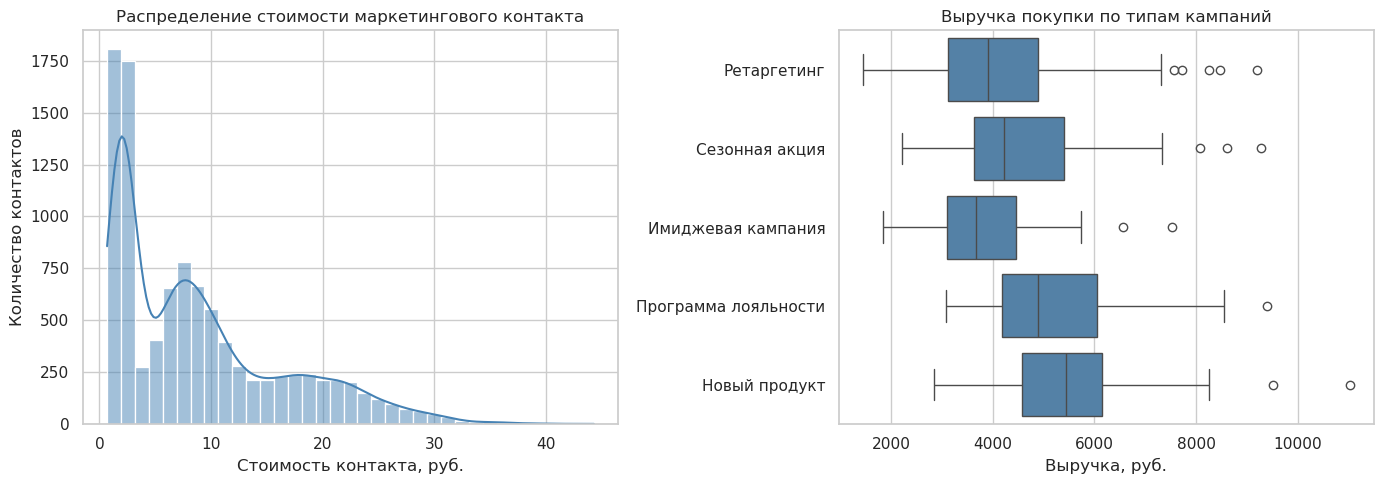

In [13]:
# Выбираем положительную выручку только по покупкам.
converted_revenue = analysis_df.loc[analysis_df['converted'] == 1, 'revenue_rub']
# Рассчитываем первый квартиль положительной выручки.
q1_revenue = converted_revenue.quantile(0.25)
# Рассчитываем третий квартиль положительной выручки.
q3_revenue = converted_revenue.quantile(0.75)
# Рассчитываем межквартильный размах.
iqr_revenue = q3_revenue - q1_revenue
# Рассчитываем верхнюю границу потенциальных выбросов.
upper_revenue_limit = q3_revenue + 1.5 * iqr_revenue
# Создаём признак потенциально крупной покупки.
analysis_df['high_revenue_outlier'] = analysis_df['revenue_rub'] > upper_revenue_limit
# Печатаем число потенциально крупных покупок.
print(f'Потенциально крупные покупки по правилу IQR: {analysis_df["high_revenue_outlier"].sum():,}')

# Создаём фигуру из двух областей.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Строим гистограмму рекламных расходов.
sns.histplot(data=analysis_df, x='ad_cost_rub', bins=35, kde=True, color='steelblue', ax=axes[0])
# Добавляем заголовок первой области.
axes[0].set_title('Распределение стоимости маркетингового контакта')
# Подписываем горизонтальную ось первой области.
axes[0].set_xlabel('Стоимость контакта, руб.')
# Подписываем вертикальную ось первой области.
axes[0].set_ylabel('Количество контактов')
# Строим boxplot положительной выручки по кампаниям.
sns.boxplot(data=analysis_df.loc[analysis_df['converted'] == 1], y='campaign_type', x='revenue_rub', color='steelblue', ax=axes[1])
# Добавляем заголовок второй области.
axes[1].set_title('Выручка покупки по типам кампаний')
# Подписываем горизонтальную ось второй области.
axes[1].set_xlabel('Выручка, руб.')
# Убираем подпись вертикальной оси второй области.
axes[1].set_ylabel('')
# Корректируем расположение элементов.
plt.tight_layout()
# Показываем графики.
plt.show()

## 18. Временная динамика

Месячная агрегация помогает увидеть изменение контактов, расходов, выручки и конверсии во времени.

Метод `groupby()` объединяет строки по месяцу. Метод `agg()` рассчитывает несколько показателей для каждой группы.

Изменение по месяцам не доказывает влияние сезона или кампании. Для причинного вывода нужен эксперимент или более строгий дизайн исследования.

,month,contacts,clicks,conversions,ad_cost_rub,revenue_rub,ctr,conversion_rate,roas
0,2025-01-01,883,124,28,"8,148.82","120,946.89",0.14,0.03,14.84
1,2025-02-01,776,111,28,"6,891.88","114,718.29",0.14,0.04,16.65
2,2025-03-01,865,105,23,"7,896.41","107,382.42",0.12,0.03,13.60
3,2025-04-01,803,111,23,"6,748.18","100,076.81",0.14,0.03,14.83
4,2025-05-01,844,110,19,"7,468.90","100,568.61",0.13,0.02,13.46
5,2025-06-01,833,100,22,"7,526.74","91,260.51",0.12,0.03,12.12
6,2025-07-01,828,106,25,"7,411.82","113,706.43",0.13,0.03,15.34
7,2025-08-01,818,116,26,"7,156.94","121,161.95",0.14,0.03,16.93
8,2025-09-01,780,99,22,"7,012.69","101,252.81",0.13,0.03,14.44
9,2025-10-01,891,114,25,"7,907.34","132,627.51",0.13,0.03,16.77


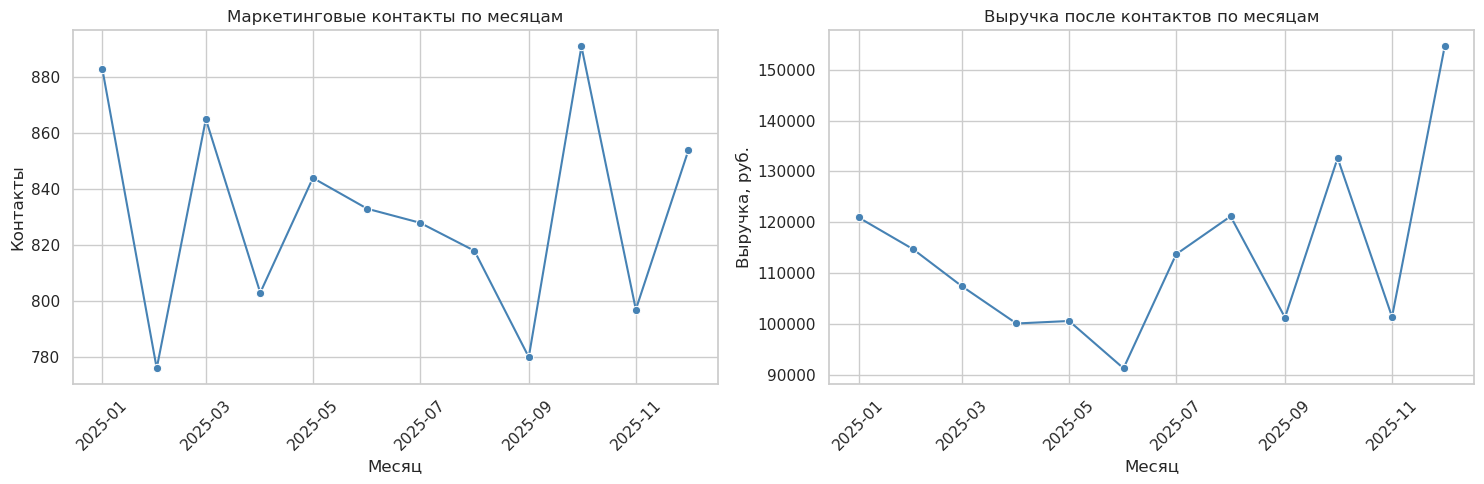

In [14]:
# Группируем контакты по календарному месяцу.
monthly_summary = analysis_df.groupby('month', as_index=False).agg(
    contacts=('contact_id', 'nunique'),
    clicks=('clicked', 'sum'),
    conversions=('converted', 'sum'),
    ad_cost_rub=('ad_cost_rub', 'sum'),
    revenue_rub=('revenue_rub', 'sum')
)
# Рассчитываем месячный CTR.
monthly_summary['ctr'] = monthly_summary['clicks'] / monthly_summary['contacts']
# Рассчитываем месячную конверсию.
monthly_summary['conversion_rate'] = monthly_summary['conversions'] / monthly_summary['contacts']
# Рассчитываем месячный ROAS.
monthly_summary['roas'] = monthly_summary['revenue_rub'] / monthly_summary['ad_cost_rub']
# Показываем месячную сводку.
display(monthly_summary)
# Создаём фигуру для динамики контактов и выручки.
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
# Строим линию количества контактов.
sns.lineplot(color='steelblue', data=monthly_summary, x='month', y='contacts', marker='o', ax=axes[0])
# Добавляем заголовок первого графика.
axes[0].set_title('Маркетинговые контакты по месяцам')
# Подписываем оси первого графика.
axes[0].set(xlabel='Месяц', ylabel='Контакты')
# Поворачиваем подписи месяцев первого графика.
axes[0].tick_params(axis='x', rotation=45)
# Строим линию выручки.
sns.lineplot(color='steelblue', data=monthly_summary, x='month', y='revenue_rub', marker='o', ax=axes[1])
# Добавляем заголовок второго графика.
axes[1].set_title('Выручка после контактов по месяцам')
# Подписываем оси второго графика.
axes[1].set(xlabel='Месяц', ylabel='Выручка, руб.')
# Поворачиваем подписи месяцев второго графика.
axes[1].tick_params(axis='x', rotation=45)
# Корректируем расположение элементов.
plt.tight_layout()
# Показываем графики.
plt.show()

## 19. Сравнение маркетинговых каналов

Для каждого канала рассчитываются объём контактов, расходы, клики, покупки, CTR, конверсия, ROAS и CPA.

Высокий CTR не гарантирует покупку. Высокий ROAS также не означает, что канал можно бесконечно масштабировать: при росте бюджета стоимость контакта и состав аудитории могут измениться.

,channel,contacts,ad_cost_rub,clicks,conversions,revenue_rub,ctr,conversion_rate,roas,cpa_rub
0,Email,2477,"5,854.14",265,66,"303,822.48",0.11,0.03,51.90,88.70
4,Социальные сети,2464,"23,813.95",338,69,"313,114.41",0.14,0.03,13.15,345.13
3,Поисковая реклама,2306,"47,420.35",461,112,"525,477.01",0.20,0.05,11.08,423.40
2,Медийная реклама,1472,"9,691.72",126,19,"88,986.64",0.09,0.01,9.18,510.09
1,Push,1253,"1,938.19",136,30,"128,281.73",0.11,0.02,66.19,64.61


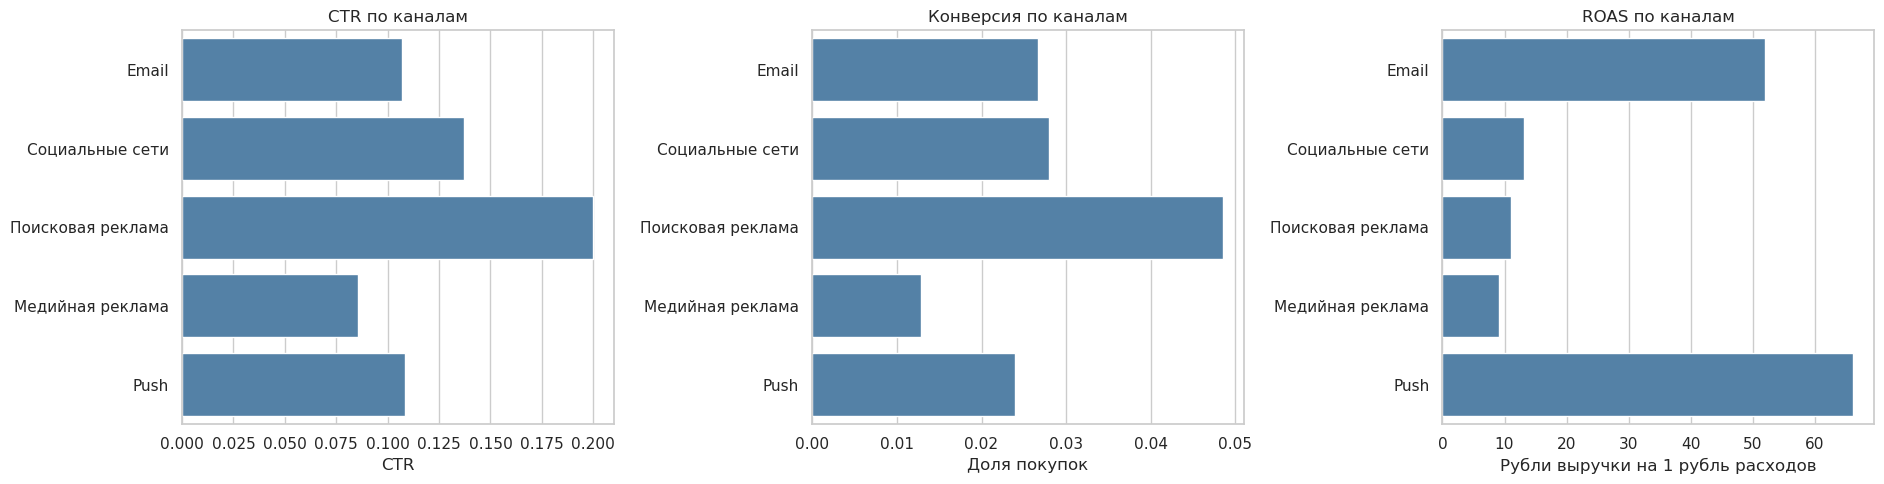

In [15]:
# Группируем контакты по маркетинговому каналу.
channel_summary = analysis_df.groupby('channel', as_index=False).agg(
    contacts=('contact_id', 'nunique'),
    ad_cost_rub=('ad_cost_rub', 'sum'),
    clicks=('clicked', 'sum'),
    conversions=('converted', 'sum'),
    revenue_rub=('revenue_rub', 'sum')
)
# Рассчитываем CTR каждого канала.
channel_summary['ctr'] = channel_summary['clicks'] / channel_summary['contacts']
# Рассчитываем конверсию каждого канала.
channel_summary['conversion_rate'] = channel_summary['conversions'] / channel_summary['contacts']
# Рассчитываем ROAS каждого канала.
channel_summary['roas'] = channel_summary['revenue_rub'] / channel_summary['ad_cost_rub']
# Рассчитываем CPA каждого канала.
channel_summary['cpa_rub'] = channel_summary['ad_cost_rub'] / channel_summary['conversions'].replace(0, np.nan)
# Сортируем каналы по числу контактов.
channel_summary = channel_summary.sort_values('contacts', ascending=False)
# Показываем сводку по каналам.
display(channel_summary)
# Создаём фигуру из трёх областей.
fig, axes = plt.subplots(1, 3, figsize=(19, 5))
# Строим CTR по каналам.
sns.barplot(color='steelblue', data=channel_summary, y='channel', x='ctr', ax=axes[0])
# Добавляем заголовок первого графика.
axes[0].set_title('CTR по каналам')
# Подписываем оси первого графика.
axes[0].set(xlabel='CTR', ylabel='')
# Строим коэффициент конверсии по каналам.
sns.barplot(color='steelblue', data=channel_summary, y='channel', x='conversion_rate', ax=axes[1])
# Добавляем заголовок второго графика.
axes[1].set_title('Конверсия по каналам')
# Подписываем оси второго графика.
axes[1].set(xlabel='Доля покупок', ylabel='')
# Строим ROAS по каналам.
sns.barplot(color='steelblue', data=channel_summary, y='channel', x='roas', ax=axes[2])
# Добавляем заголовок третьего графика.
axes[2].set_title('ROAS по каналам')
# Подписываем оси третьего графика.
axes[2].set(xlabel='Рубли выручки на 1 рубль расходов', ylabel='')
# Корректируем расположение элементов.
plt.tight_layout()
# Показываем графики.
plt.show()

## 20. Кампании, сегменты и тепловая карта

Тепловая карта кодирует число цветом. В данном случае каждая ячейка показывает коэффициент конверсии для сочетания кампании и клиентского сегмента.

Более насыщенный цвет означает более высокую долю покупок. Однако маленькая группа может давать нестабильную долю, поэтому перед решением нужно учитывать число наблюдений.

,campaign_type,contacts,ad_cost_rub,clicks,conversions,revenue_rub,conversion_rate,roas
3,Ретаргетинг,2264,"18,215.24",379,94,"394,129.81",0.04,21.64
2,Программа лояльности,1747,"12,761.90",183,48,"249,010.83",0.03,19.51
4,Сезонная акция,2305,"21,980.63",344,74,"339,172.97",0.03,15.43
1,Новый продукт,1740,"17,908.39",218,39,"217,626.17",0.02,12.15
0,Имиджевая кампания,1916,"17,852.19",202,41,"159,742.49",0.02,8.95


customer_segment,Лояльный,Новый,Повторный
campaign_type,,,
Имиджевая кампания,378,699,839
Новый продукт,336,640,764
Программа лояльности,377,654,716
Ретаргетинг,451,889,924
Сезонная акция,443,903,959


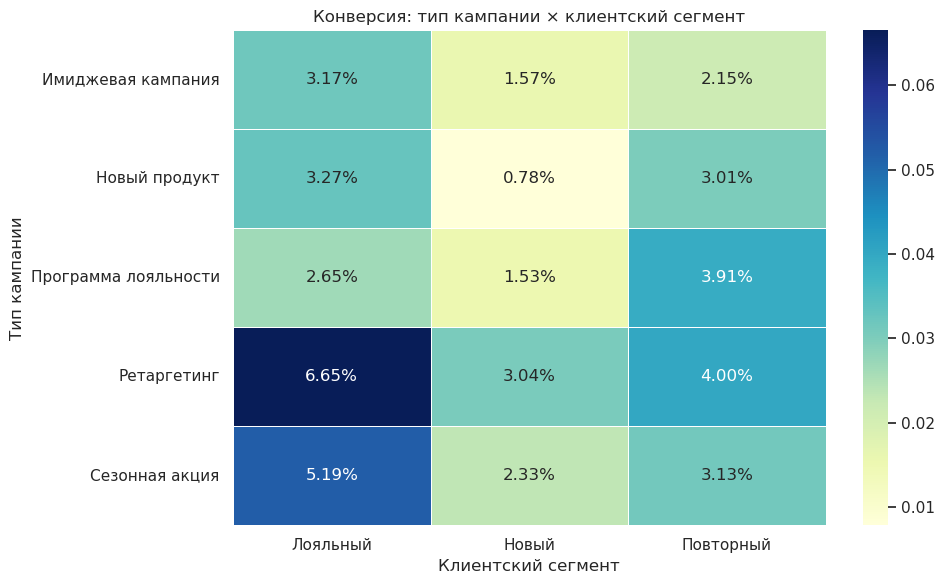

In [16]:
# Группируем данные по типу кампании.
campaign_summary = analysis_df.groupby('campaign_type', as_index=False).agg(
    contacts=('contact_id', 'nunique'),
    ad_cost_rub=('ad_cost_rub', 'sum'),
    clicks=('clicked', 'sum'),
    conversions=('converted', 'sum'),
    revenue_rub=('revenue_rub', 'sum')
)
# Рассчитываем конверсию кампании.
campaign_summary['conversion_rate'] = campaign_summary['conversions'] / campaign_summary['contacts']
# Рассчитываем ROAS кампании.
campaign_summary['roas'] = campaign_summary['revenue_rub'] / campaign_summary['ad_cost_rub']
# Сортируем кампании по ROAS.
campaign_summary = campaign_summary.sort_values('roas', ascending=False)
# Показываем сводку по кампаниям.
display(campaign_summary)

# Создаём сводную таблицу конверсии «кампания × сегмент».
segment_campaign_conversion = analysis_df.pivot_table(index='campaign_type', columns='customer_segment', values='converted', aggfunc='mean')
# Создаём сводную таблицу числа контактов «кампания × сегмент».
segment_campaign_count = analysis_df.pivot_table(index='campaign_type', columns='customer_segment', values='contact_id', aggfunc='count')
# Показываем число наблюдений в каждой ячейке.
display(segment_campaign_count)
# Создаём фигуру для тепловой карты.
plt.figure(figsize=(10, 6))
# Строим тепловую карту коэффициента конверсии.
sns.heatmap(segment_campaign_conversion, annot=True, fmt='.2%', cmap='YlGnBu', linewidths=0.5)
# Добавляем заголовок.
plt.title('Конверсия: тип кампании × клиентский сегмент')
# Подписываем горизонтальную ось.
plt.xlabel('Клиентский сегмент')
# Подписываем вертикальную ось.
plt.ylabel('Тип кампании')
# Корректируем расположение элементов.
plt.tight_layout()
# Показываем тепловую карту.
plt.show()

## 21. Маркетинговая воронка и устройства

Воронка показывает последовательность этапов: контакт, клик и покупка. Каждый следующий этап не может быть больше предыдущего в рамках принятой модели.

Переход от контакта к клику измеряется CTR. Переход от клика к покупке измеряется post-click conversion rate.

Сравнение устройств является описательным. Оно не доказывает, что устройство вызывает изменение покупательского поведения: тип устройства может быть связан с каналом, кампанией и составом аудитории.

,stage,count
0,Контакты,9972
1,Клики,1326
2,Покупки,296


,device_type,contacts,clicks,conversions,ctr,conversion_rate
0,Компьютер,3045,396,92,0.13,0.03
1,Мобильное устройство,6412,878,192,0.14,0.03
2,Планшет,515,52,12,0.10,0.02


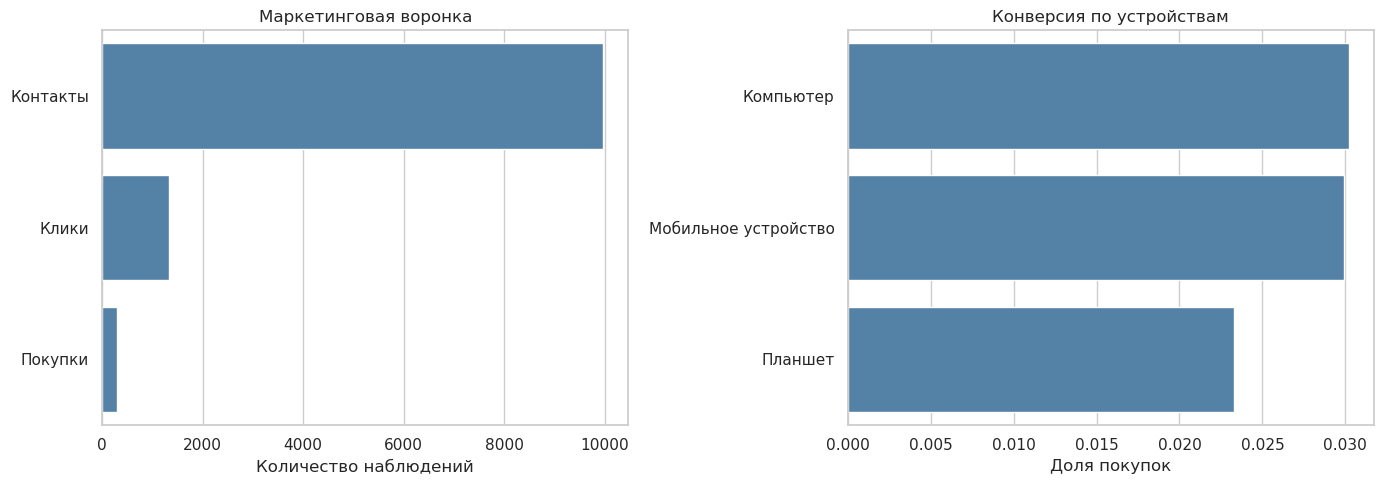

In [17]:
# Создаём таблицу этапов маркетинговой воронки.
funnel_table = pd.DataFrame({
    'stage': ['Контакты', 'Клики', 'Покупки'],
    'count': [total_contacts, total_clicks, total_conversions]
})
# Показываем таблицу воронки.
display(funnel_table)
# Группируем данные по типу устройства.
device_summary = analysis_df.groupby('device_type', as_index=False).agg(
    contacts=('contact_id', 'nunique'),
    clicks=('clicked', 'sum'),
    conversions=('converted', 'sum')
)
# Рассчитываем CTR по устройствам.
device_summary['ctr'] = device_summary['clicks'] / device_summary['contacts']
# Рассчитываем конверсию по устройствам.
device_summary['conversion_rate'] = device_summary['conversions'] / device_summary['contacts']
# Показываем сводку по устройствам.
display(device_summary)
# Создаём фигуру из двух областей.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Строим воронку горизонтальными столбцами.
sns.barplot(color='steelblue', data=funnel_table, y='stage', x='count', ax=axes[0])
# Добавляем заголовок первой области.
axes[0].set_title('Маркетинговая воронка')
# Подписываем оси первой области.
axes[0].set(xlabel='Количество наблюдений', ylabel='')
# Строим конверсию по устройствам.
sns.barplot(color='steelblue', data=device_summary, y='device_type', x='conversion_rate', ax=axes[1])
# Добавляем заголовок второй области.
axes[1].set_title('Конверсия по устройствам')
# Подписываем оси второй области.
axes[1].set(xlabel='Доля покупок', ylabel='')
# Корректируем расположение элементов.
plt.tight_layout()
# Показываем графики.
plt.show()

## 22. Корреляционная матрица

Корреляция показывает направление и силу линейной или монотонной связи между числовыми признаками.

Используется коэффициент Спирмена. Он сравнивает ранги значений и меньше зависит от формы распределения и отдельных крупных покупок, чем коэффициент Пирсона.

Значение около +1 означает положительную связь. Значение около −1 означает обратную связь. Значение около нуля означает отсутствие выраженной монотонной связи.

Корреляция не доказывает причинность. Например, `converted` и `revenue_rub` связаны по определению данных, потому что выручка появляется только при покупке.

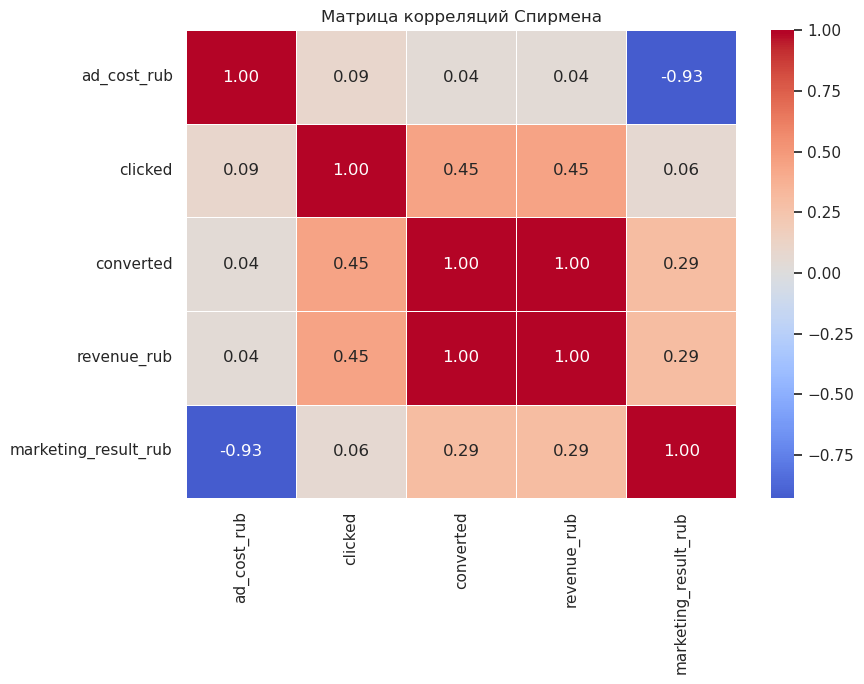

In [18]:
# Выбираем числовые признаки для корреляционного анализа.
correlation_columns = ['ad_cost_rub', 'clicked', 'converted', 'revenue_rub', 'marketing_result_rub']
# Рассчитываем корреляцию Спирмена.
correlation_matrix = analysis_df[correlation_columns].corr(method='spearman')
# Создаём фигуру для тепловой карты корреляций.
plt.figure(figsize=(9, 7))
# Строим тепловую карту с числовыми подписями коэффициентов.
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
# Добавляем заголовок.
plt.title('Матрица корреляций Спирмена')
# Корректируем расположение элементов.
plt.tight_layout()
# Показываем тепловую карту.
plt.show()

## 23. Статистическая проверка связи канала и покупки

Проверяется вопрос: связан ли маркетинговый канал с фактом покупки.

- Нулевая гипотеза H0: канал и покупка статистически независимы.
- Альтернативная гипотеза H1: между каналом и покупкой есть статистическая связь.

Используется критерий хи-квадрат для таблицы сопряжённости. Таблица показывает число покупок и отсутствий покупки по каждому каналу.

`p-value` показывает, насколько необычен полученный результат при условии справедливости H0. Порог `alpha = 0.05` задаётся заранее.

Размер эффекта оценивается коэффициентом V Крамера. Он находится от 0 до 1. Значение около нуля означает слабую связь. Даже статистически значимая связь может быть практически небольшой при большой выборке.

In [19]:
# Строим таблицу сопряжённости «канал × покупка».
contingency_table = pd.crosstab(analysis_df['channel'], analysis_df['converted'])
# Показываем фактические количества наблюдений.
display(contingency_table)
# Задаём уровень статистической значимости.
alpha = 0.05
# Выполняем критерий хи-квадрат.
chi2_statistic, p_value, degrees_of_freedom, expected_frequencies = chi2_contingency(contingency_table)
# Создаём таблицу ожидаемых частот при независимости признаков.
expected_table = pd.DataFrame(expected_frequencies, index=contingency_table.index, columns=contingency_table.columns)
# Показываем ожидаемые частоты.
display(expected_table)
# Рассчитываем общее число наблюдений в таблице сопряжённости.
contingency_n = contingency_table.to_numpy().sum()
# Рассчитываем минимальную размерность таблицы для V Крамера.
minimum_dimension = min(contingency_table.shape[0] - 1, contingency_table.shape[1] - 1)
# Рассчитываем V Крамера.
cramers_v = np.sqrt(chi2_statistic / (contingency_n * minimum_dimension))
# Печатаем статистику хи-квадрат.
print(f'Хи-квадрат: {chi2_statistic:,.3f}')
# Печатаем число степеней свободы.
print(f'Степени свободы: {degrees_of_freedom}')
# Печатаем p-value.
print(f'p-value: {p_value:.6g}')
# Печатаем размер эффекта.
print(f'V Крамера: {cramers_v:.3f}')
# Проверяем минимальную ожидаемую частоту.
print(f'Минимальная ожидаемая частота: {expected_table.min().min():.2f}')
# Формулируем статистическое решение без причинного утверждения.
if p_value < alpha:
    # Печатаем решение при статистически значимом результате.
    print('H0 отклоняется: в синтетическом наборе канал связан с фактом покупки.')
else:
    # Печатаем решение при недостатке оснований для отклонения H0.
    print('Недостаточно оснований отклонить H0 на уровне значимости 5%.')

converted,0,1
channel,,
Email,2411,66
Push,1223,30
Медийная реклама,1453,19
Поисковая реклама,2194,112
Социальные сети,2395,69


converted,0,1
channel,,
Email,"2,403.47",73.53
Push,"1,215.81",37.19
Медийная реклама,"1,428.31",43.69
Поисковая реклама,"2,237.55",68.45
Социальные сети,"2,390.86",73.14


Хи-квадрат: 45.408
Степени свободы: 4
p-value: 3.27026e-09
V Крамера: 0.067
Минимальная ожидаемая частота: 37.19
H0 отклоняется: в синтетическом наборе канал связан с фактом покупки.


## 24. Итоговый дашборд

Дашборд объединяет шесть графиков:

1. контакты по месяцам;
2. выручка по месяцам;
3. контакты по каналам;
4. конверсия по каналам;
5. ROAS по типам кампаний;
6. тепловая карта «кампания × сегмент».

Дашборд служит компактной панелью первичного контроля. Он не заменяет проверку качества данных, статистический анализ и чтение ограничений.

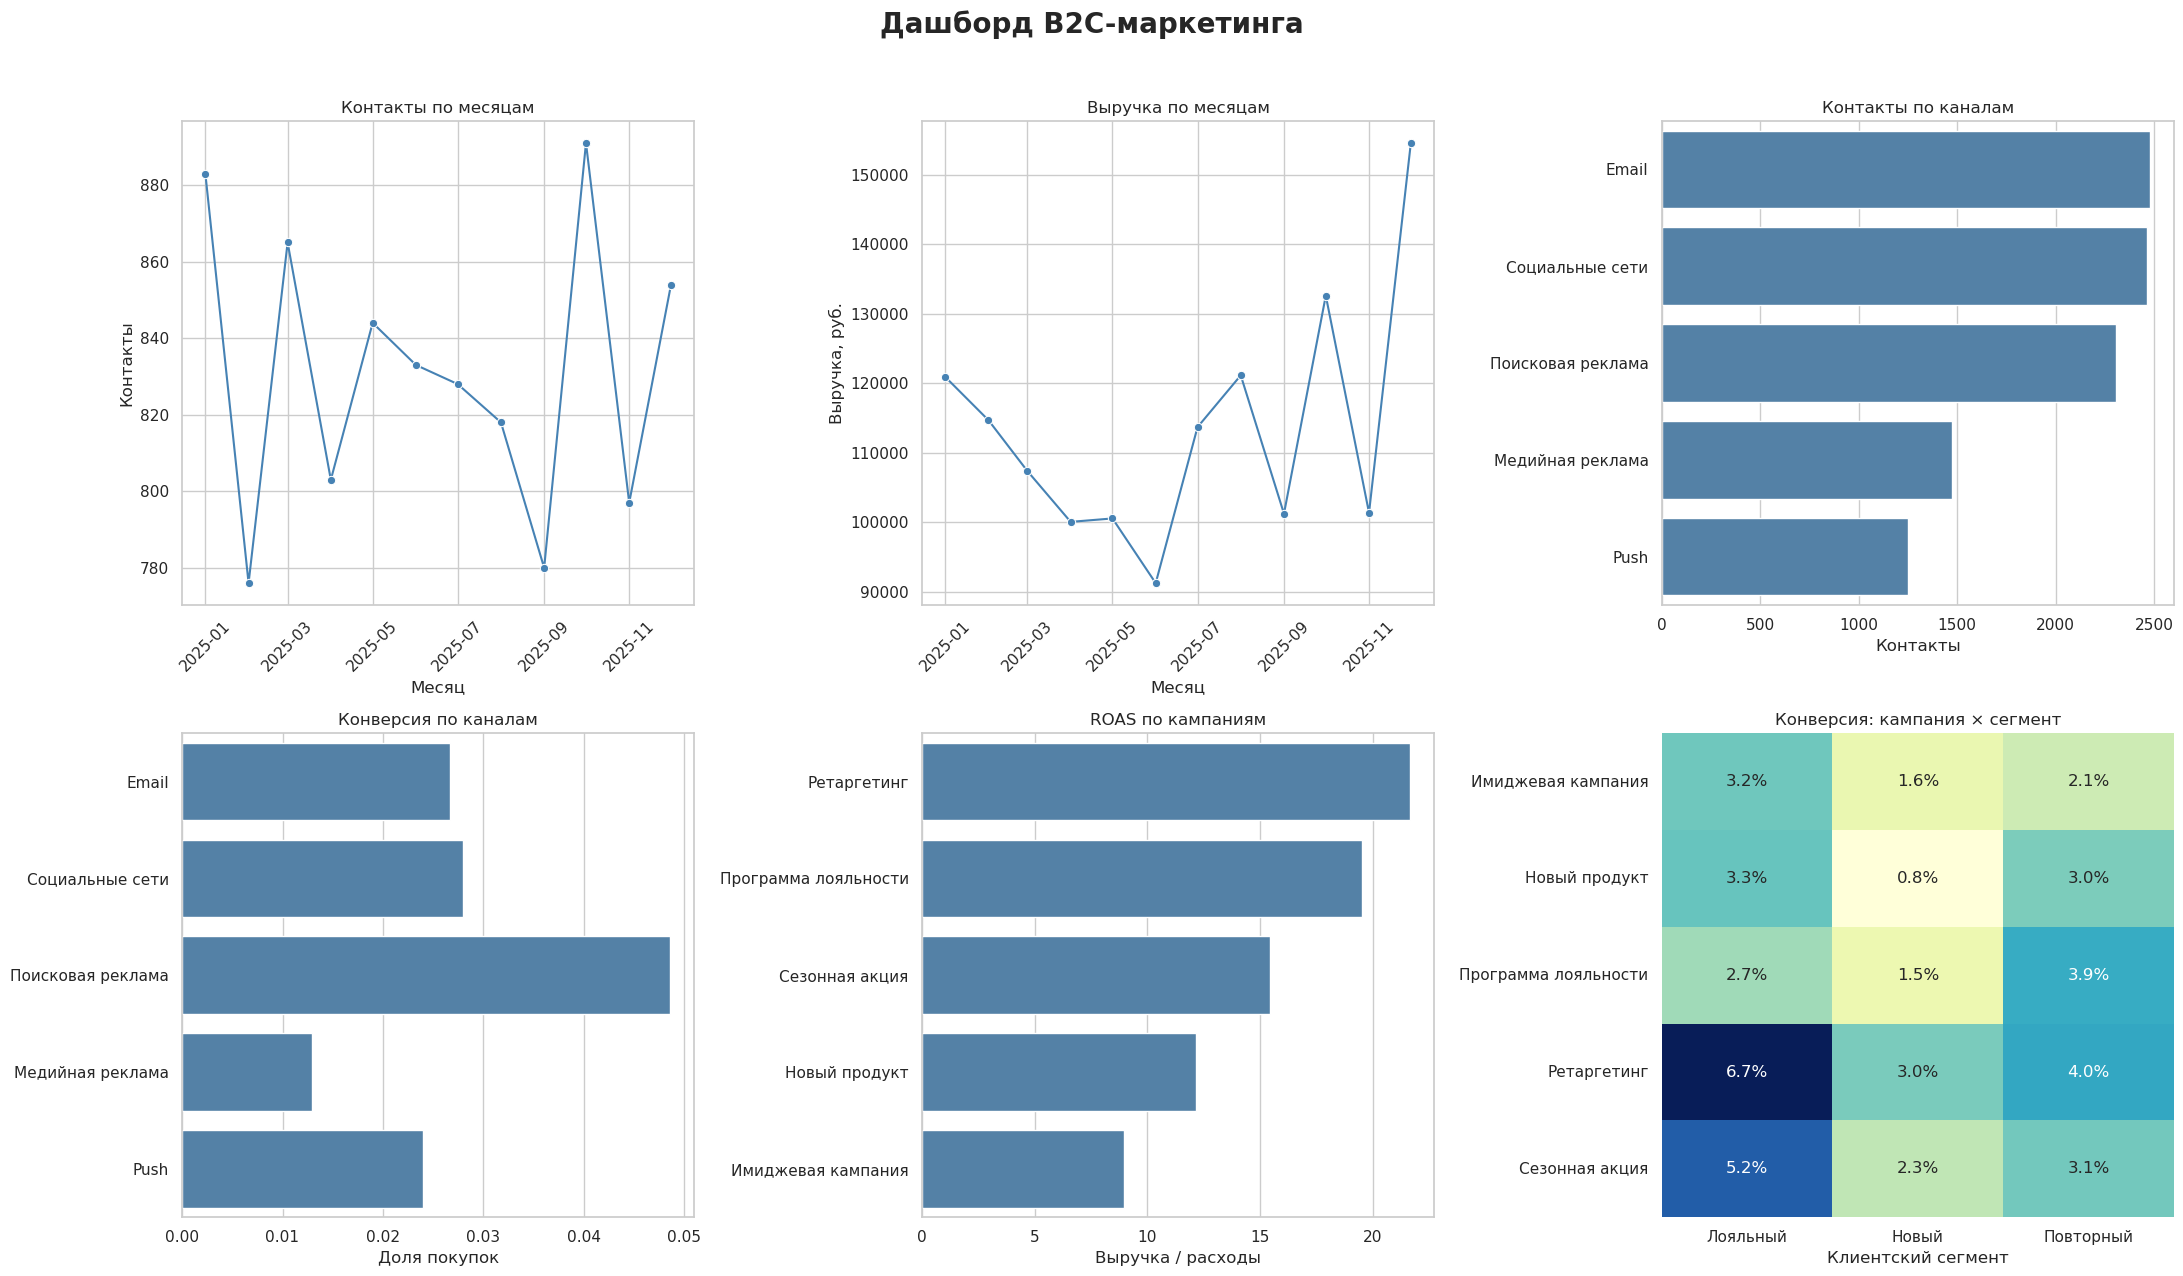

Дашборд сохранён: /home/jovyan/work/28_07_2026/example_two/b2c_marketing_dashboard.png


In [20]:
# Создаём фигуру дашборда из двух строк и трёх столбцов.
fig, axes = plt.subplots(2, 3, figsize=(22, 13))
# Добавляем общий заголовок дашборда.
fig.suptitle('Дашборд B2C-маркетинга', fontsize=20, fontweight='bold')

# Строим месячную динамику контактов.
sns.lineplot(color='steelblue', data=monthly_summary, x='month', y='contacts', marker='o', ax=axes[0, 0])
# Настраиваем заголовок первого графика.
axes[0, 0].set_title('Контакты по месяцам')
# Подписываем оси первого графика.
axes[0, 0].set(xlabel='Месяц', ylabel='Контакты')
# Поворачиваем подписи месяцев первого графика.
axes[0, 0].tick_params(axis='x', rotation=45)

# Строим месячную динамику выручки.
sns.lineplot(color='steelblue', data=monthly_summary, x='month', y='revenue_rub', marker='o', ax=axes[0, 1])
# Настраиваем заголовок второго графика.
axes[0, 1].set_title('Выручка по месяцам')
# Подписываем оси второго графика.
axes[0, 1].set(xlabel='Месяц', ylabel='Выручка, руб.')
# Поворачиваем подписи месяцев второго графика.
axes[0, 1].tick_params(axis='x', rotation=45)

# Строим объём контактов по каналам.
sns.barplot(color='steelblue', data=channel_summary, y='channel', x='contacts', ax=axes[0, 2])
# Настраиваем заголовок третьего графика.
axes[0, 2].set_title('Контакты по каналам')
# Подписываем оси третьего графика.
axes[0, 2].set(xlabel='Контакты', ylabel='')

# Строим конверсию по каналам.
sns.barplot(color='steelblue', data=channel_summary, y='channel', x='conversion_rate', ax=axes[1, 0])
# Настраиваем заголовок четвёртого графика.
axes[1, 0].set_title('Конверсия по каналам')
# Подписываем оси четвёртого графика.
axes[1, 0].set(xlabel='Доля покупок', ylabel='')

# Строим ROAS по типам кампаний.
sns.barplot(color='steelblue', data=campaign_summary, y='campaign_type', x='roas', ax=axes[1, 1])
# Настраиваем заголовок пятого графика.
axes[1, 1].set_title('ROAS по кампаниям')
# Подписываем оси пятого графика.
axes[1, 1].set(xlabel='Выручка / расходы', ylabel='')

# Строим тепловую карту конверсии кампаний и сегментов.
sns.heatmap(segment_campaign_conversion, annot=True, fmt='.1%', cmap='YlGnBu', cbar=False, ax=axes[1, 2])
# Настраиваем заголовок шестого графика.
axes[1, 2].set_title('Конверсия: кампания × сегмент')
# Подписываем горизонтальную ось шестого графика.
axes[1, 2].set_xlabel('Клиентский сегмент')
# Подписываем вертикальную ось шестого графика.
axes[1, 2].set_ylabel('')

# Корректируем расположение элементов с учётом общего заголовка.
plt.tight_layout(rect=[0, 0, 1, 0.96])
# Сохраняем дашборд в PNG с высоким разрешением.
fig.savefig(DASHBOARD_PATH, dpi=180, bbox_inches='tight')
# Показываем дашборд.
plt.show()
# Печатаем путь к сохранённому дашборду.
print(f'Дашборд сохранён: {DASHBOARD_PATH.resolve()}')

## 25. Выводы, ограничения, рекомендации и финальный QA

### Ограничения

- Датасет синтетический и не описывает реальную маркетинговую систему.
- Одна строка представляет контакт, а не уникального клиента. Повторные контакты одного человека не отслеживаются.
- В модели покупка возможна только после клика. Реальные системы атрибуции могут учитывать просмотры без клика и несколько каналов.
- ROAS не равен прибыли, потому что отсутствуют себестоимость, логистика, возвраты, налоги и операционные расходы.
- Статистическая связь канала с покупкой не доказывает причинный эффект канала.
- Для реального решения потребовались бы A/B-тест, контроль сезонности, единица рандомизации и защита от пересечения аудиторий.

### Практические рекомендации

- сравнивать каналы одновременно по CTR, конверсии, CPA и ROAS;
- не масштабировать кампанию только по высокому CTR;
- отдельно контролировать размер выборки каждого сегмента;
- проверять кампании с высоким ROAS на устойчивость при увеличении бюджета;
- для реальной компании добавить идентификатор клиента, товарную категорию, атрибуционное окно, маржу и источник заказа;
- проверять изменения бюджета через корректно спроектированный эксперимент.

In [21]:
# Находим месяц с максимальным числом контактов.
peak_contacts_month = monthly_summary.loc[monthly_summary['contacts'].idxmax()]
# Находим канал с максимальной конверсией.
best_conversion_channel = channel_summary.loc[channel_summary['conversion_rate'].idxmax()]
# Находим канал с минимальной стоимостью покупки.
best_cpa_channel = channel_summary.loc[channel_summary['cpa_rub'].idxmin()]
# Находим кампанию с максимальным ROAS.
best_roas_campaign = campaign_summary.loc[campaign_summary['roas'].idxmax()]
# Находим сегмент с максимальной общей конверсией.
segment_summary = analysis_df.groupby('customer_segment', as_index=False).agg(contacts=('contact_id', 'nunique'), conversions=('converted', 'sum'))
# Рассчитываем конверсию каждого сегмента.
segment_summary['conversion_rate'] = segment_summary['conversions'] / segment_summary['contacts']
# Выбираем сегмент с максимальной конверсией.
best_segment = segment_summary.loc[segment_summary['conversion_rate'].idxmax()]
# Формируем итоговый текст на основании выполненных расчётов.
final_text = f'''
### Итоговые наблюдения по синтетическим данным

- После очистки анализируется **{total_contacts:,} уникальных маркетинговых контактов**.
- Получено **{total_clicks:,} кликов** и **{total_conversions:,} покупок**.
- Общий CTR составляет **{ctr:.1%}**, а коэффициент конверсии — **{conversion_rate:.1%}**.
- Учебный ROAS составляет **{roas:.2f}**, то есть на один рубль рекламных расходов приходится {roas:.2f} рубля выручки.
- Максимальный месячный объём наблюдается в **{peak_contacts_month['month']:%Y-%m}**: **{int(peak_contacts_month['contacts']):,} контактов**.
- Наибольшая конверсия наблюдается у канала **{best_conversion_channel['channel']}**: **{best_conversion_channel['conversion_rate']:.1%}**.
- Минимальный CPA наблюдается у канала **{best_cpa_channel['channel']}**: **{best_cpa_channel['cpa_rub']:,.0f} руб.**
- Максимальный ROAS наблюдается у кампании **{best_roas_campaign['campaign_type']}**: **{best_roas_campaign['roas']:.2f}**.
- Наибольшая конверсия среди сегментов наблюдается у группы **{best_segment['customer_segment']}**: **{best_segment['conversion_rate']:.1%}**.
- Критерий хи-квадрат дал p-value **{p_value:.4g}**, а V Крамера равен **{cramers_v:.3f}**.

Эти наблюдения описывают синтетический набор. Они не являются доказательством причинного влияния канала, кампании или сегмента на покупку.
'''
# Показываем итоговый текст как Markdown.
display(Markdown(final_text))

# Сохраняем очищенный набор только с исходными десятью столбцами.
df[critical_columns].to_csv(CLEAN_DATA_PATH, index=False, encoding='utf-8-sig')
# Проверяем исходный размер датасета.
assert raw_df.shape == (10000, 10), 'Исходный CSV должен содержать 10 000 строк и 10 столбцов.'
# Проверяем, что очищенный набор содержит только десять столбцов.
assert df[critical_columns].shape[1] == 10, 'Очищенный CSV должен содержать десять столбцов.'
# Проверяем совпадение числа уникальных контактов и строк очищенной таблицы.
assert df['contact_id'].nunique() == len(df), 'Количество уникальных контактов не совпадает с числом строк.'
# Проверяем совпадение общих расходов и агрегации по каналам.
assert np.isclose(total_ad_cost, channel_summary['ad_cost_rub'].sum()), 'Контроль расходов по каналам не пройден.'
# Проверяем совпадение общей выручки и агрегации по кампаниям.
assert np.isclose(total_revenue, campaign_summary['revenue_rub'].sum()), 'Контроль выручки по кампаниям не пройден.'
# Проверяем порядок этапов воронки.
assert total_contacts >= total_clicks >= total_conversions, 'Этапы маркетинговой воронки нарушены.'
# Проверяем конечность статистического результата.
assert np.isfinite(p_value), 'p-value должен быть конечным числом.'
# Проверяем допустимый диапазон V Крамера.
assert 0 <= cramers_v <= 1, 'V Крамера должен находиться от 0 до 1.'
# Проверяем пригодность ожидаемых частот критерия хи-квадрат.
assert expected_table.min().min() >= 5, 'Есть слишком маленькие ожидаемые частоты для критерия хи-квадрат.'
# Проверяем существование очищенного CSV.
assert CLEAN_DATA_PATH.exists(), 'Очищенный CSV не сохранён.'
# Проверяем существование дашборда.
assert DASHBOARD_PATH.exists(), 'Дашборд не сохранён.'
# Печатаем финальный статус QA.
print('QA PASSED: notebook выполнен, данные очищены, метрики согласованы, статистический тест проверен, файлы сохранены.')


### Итоговые наблюдения по синтетическим данным

- После очистки анализируется **9,972 уникальных маркетинговых контактов**.
- Получено **1,326 кликов** и **296 покупок**.
- Общий CTR составляет **13.3%**, а коэффициент конверсии — **3.0%**.
- Учебный ROAS составляет **15.33**, то есть на один рубль рекламных расходов приходится 15.33 рубля выручки.
- Максимальный месячный объём наблюдается в **2025-10**: **891 контактов**.
- Наибольшая конверсия наблюдается у канала **Поисковая реклама**: **4.9%**.
- Минимальный CPA наблюдается у канала **Push**: **65 руб.**
- Максимальный ROAS наблюдается у кампании **Ретаргетинг**: **21.64**.
- Наибольшая конверсия среди сегментов наблюдается у группы **Лояльный**: **4.3%**.
- Критерий хи-квадрат дал p-value **3.27e-09**, а V Крамера равен **0.067**.

Эти наблюдения описывают синтетический набор. Они не являются доказательством причинного влияния канала, кампании или сегмента на покупку.


QA PASSED: notebook выполнен, данные очищены, метрики согласованы, статистический тест проверен, файлы сохранены.


### Источники по структуре и методам

- Универсальный аналитический пайплайн: https://github.com/q10sn1k/DA_MAY_2026/blob/main/item_7/universal_analytics_pipeline_steps.md
- Pandas: https://pandas.pydata.org/docs/
- Matplotlib: https://matplotlib.org/stable/
- Seaborn heatmap: https://seaborn.pydata.org/generated/seaborn.heatmap.html
- SciPy chi-square contingency test: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.chi2_contingency.html

Документация библиотек может изменяться между версиями. Для воспроизведения используются зависимости из файла `requirements_b2c_marketing_analysis.txt`.